# Sales Data Analysis and Reporting

## Project Overview
The objective of this project is to analyze retail transaction data and identify customer purchasing patterns, revenue trends, and marketing campaign effectiveness.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The transaction and customer response datasets are loaded into Pandas DataFrames for further analysis.


In [2]:
transactions = pd.read_csv("../data/Retail_Data_Transactions.csv")
response = pd.read_csv("../data/Retail_Data_Response.csv")


Let's inspect the first few rows of the datasets.


In [3]:
transactions.head()


,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78


In [4]:
response.head()


,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1


In [5]:
transactions.info()


<class 'pandas.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   customer_id  125000 non-null  str  
 1   trans_date   125000 non-null  str  
 2   tran_amount  125000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 2.9 MB


In [6]:
response.info()


<class 'pandas.DataFrame'>
RangeIndex: 6884 entries, 0 to 6883
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  6884 non-null   str  
 1   response     6884 non-null   int64
dtypes: int64(1), str(1)
memory usage: 107.7 KB


## Data Cleaning

We ensure data quality by checking for and removing missing values, duplicates, and standardizing date formats.


In [7]:
transactions.isnull().sum()


customer_id    0
trans_date     0
tran_amount    0
dtype: int64

In [8]:
response.isnull().sum()


customer_id    0
response       0
dtype: int64

In [9]:
transactions.dropna(inplace=True)
response.dropna(inplace=True)


In [10]:
transactions.drop_duplicates(inplace=True)
response.drop_duplicates(inplace=True)


In [11]:
transactions["trans_date"] = pd.to_datetime(transactions["trans_date"])


C:\Users\zaids\AppData\Local\Temp\ipykernel_22256\2379496931.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transactions["trans_date"] = pd.to_datetime(transactions["trans_date"])


In [12]:
transactions.info()


<class 'pandas.DataFrame'>
Index: 124994 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  124994 non-null  str           
 1   trans_date   124994 non-null  datetime64[us]
 2   tran_amount  124994 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 3.8 MB


## Data Preparation

We merge the datasets and extract useful temporal features like Year, Month, and Quarter for time-series analysis.


In [13]:
df = pd.merge(transactions, response, on="customer_id", how="inner")


In [14]:
df["Year"] = df["trans_date"].dt.year
df["Month"] = df["trans_date"].dt.month
df["Quarter"] = df["trans_date"].dt.quarter


## Exploratory Data Analysis

We will answer critical business questions regarding revenue, customer spending, and campaign engagement.


### Total Revenue


In [15]:
df["tran_amount"].sum()


np.int64(8122062)

### Average Transaction


In [16]:
df["tran_amount"].mean()


np.float64(64.9957347374823)

### Top 10 Customers


In [17]:
top_customers = (
    df.groupby("customer_id")["tran_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers


customer_id
CS4424    2933
CS4320    2647
CS5752    2612
CS4660    2527
CS3799    2513
CS5109    2506
CS4074    2462
CS3805    2453
CS4608    2449
CS5555    2439
Name: tran_amount, dtype: int64

### Revenue by Year


In [18]:
df.groupby("Year")["tran_amount"].sum()


Year
2011    1339965
2012    2115475
2013    2137124
2014    2094363
2015     435135
Name: tran_amount, dtype: int64

### Revenue by Month


In [19]:
df.groupby("Month")["tran_amount"].sum()


Month
1     724089
2     644988
3     636400
4     515746
5     633162
6     697014
7     716995
8     726775
9     694134
10    725010
11    698024
12    709725
Name: tran_amount, dtype: int64

### Customer Response


In [20]:
df["response"].value_counts()


response
0    111122
1     13841
Name: count, dtype: int64

## Visualizations

Visualizing the key metrics to identify trends and seasonal peaks.


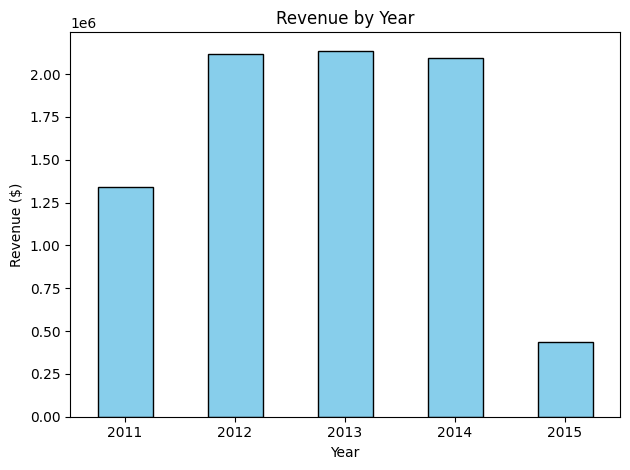

In [21]:
yearly = df.groupby("Year")["tran_amount"].sum()
yearly.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


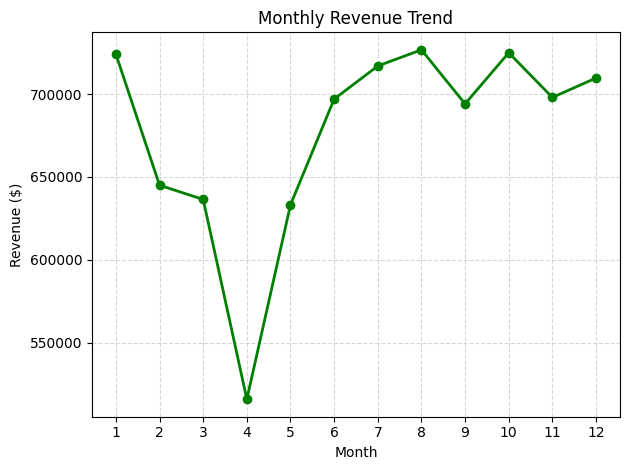

In [22]:
monthly = df.groupby("Month")["tran_amount"].sum()
monthly.plot(kind="line", marker="o", color="green", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Top 10 Customers


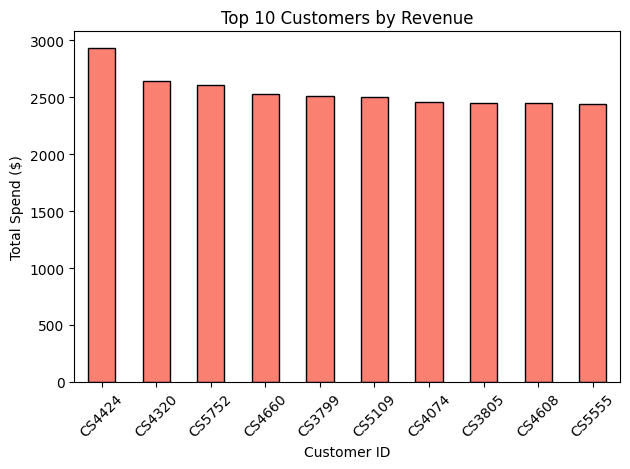

In [23]:
top_customers.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


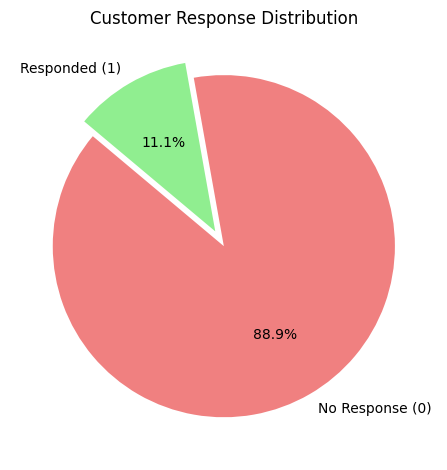

In [24]:
df["response"].value_counts().plot(
    kind="pie",
    labels=["No Response (0)", "Responded (1)"],
    autopct="%1.1f%%",
    colors=["lightcoral", "lightgreen"],
    startangle=140,
    explode=(0, 0.1)
)
plt.title("Customer Response Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Customer Segmentation

We classify customers into High Value, Medium Value, and Low Value based on their total spend using percentile thresholds.


In [25]:
customer_spend = df.groupby("customer_id")["tran_amount"].sum()
customer_spend.describe()


count    6884.000000
mean     1179.846310
std       465.422455
min       149.000000
25%       781.000000
50%      1228.000000
75%      1520.250000
max      2933.000000
Name: tran_amount, dtype: float64

In [26]:
p25 = customer_spend.quantile(0.25)
p75 = customer_spend.quantile(0.75)

def classify_customer(spend):
    if spend > p75:
        return "High Value"
    elif spend < p25:
        return "Low Value"
    else:
        return "Medium Value"

customer_segments = customer_spend.apply(classify_customer)
segment_counts = customer_segments.value_counts()
segment_counts


tran_amount
Medium Value    3448
High Value      1721
Low Value       1715
Name: count, dtype: int64

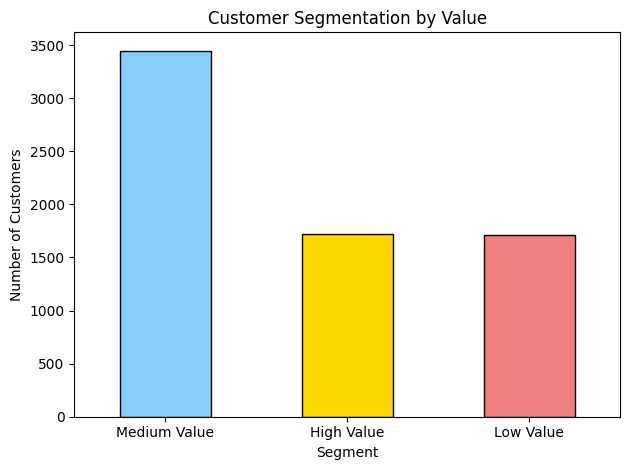

In [27]:
segment_counts.plot(kind="bar", color=["lightskyblue", "gold", "lightcoral"], edgecolor="black")
plt.title("Customer Segmentation by Value")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Key Findings

- Total revenue generated was $8,122,062.
- Top customers contributed significantly to sales.
- Revenue peaked during specific months.
- Marketing response rate was 11.1%.


## Recommendations

1. Focus marketing efforts on high-value customers.
2. Increase promotions during low-revenue months.
3. Improve campaign targeting to increase response rates.
4. Develop loyalty programs for repeat customers.


## Conclusion

The analysis provided insights into customer behavior, revenue trends, and campaign effectiveness, helping support business decision-making.
